# USAGE — How to use the `Scoring` class

This notebook explains, in English, how to use the `Scoring` class and its related helper functions:

- `fit_spline_mu_classic`
- `fit_spline_mu`
- `compute_score_for_k`
- `Scoring.fit_spline_mu`
- `Scoring.evaluation_scoring`
- `Scoring.evaluate_metrics`
- `Scoring._plot`
- `Scoring._plot_matrice`
- `Scoring._plot_fixed_effects`

The notebook focuses on three questions:

1. **What is the model fitted internally?**
2. **How is each monotonic score computed?**
3. **How should the plots be read?**

---

## 1. High-level idea

The class evaluates an ordinal prediction `score` against a continuous target `Y` by estimating a smooth conditional mean curve:

\[
Y \approx \mu(score, zone, date)
\]

In the sparse implementation used by `fit_spline_mu`, the fitted model is:

\[
Y = \beta_0 + f(score) + FE_{zone} + FE_{date} + \varepsilon,
\]

where:

- \(f(score)\) is a B-spline function,
- `FE_zone` and `FE_date` are optional fixed effects,
- a curvature penalty is applied to the spline coefficients,
- the full problem is solved as a **sparse least-squares** system.

This design is useful when:

- the relationship between score and outcome is not exactly linear,
- many zones and/or dates must be adjusted for,
- the number of observations is large enough that dense dummy matrices become expensive.

The implementation uses official Python tooling for all of these building blocks:
`SplineTransformer` and `OneHotEncoder` from scikit-learn, `lsqr` from SciPy, and the formula API of statsmodels / Patsy for the classic dense version.  
See the official references at the end of the notebook.


## 2. What the class returns

The core object returned by the monotonic evaluation is the estimated level profile:

\[
\mu(0), \mu(1), \mu(2), \mu(3), \mu(4),
\]

plus a dense curve `mu_dense` used for plotting.

From these values, the class computes transition effects

\[
\Delta_{a \to b} = \mu(b) - \bigl(\mu(a) + \text{min\_gain}_k\bigr),
\quad \text{for } a < b,\; k=b-a.
\]

For each order \(k \in \{1,2,3,4\}\), the code summarizes the normalized transition effects with:

- **median effect**,
- **worst transition**,
- **average negative mass**,
- **violation rate**.

The final score for a given `k` is:

\[
\text{score}_k
=
\frac{w_{\text{avg}} \cdot \text{median}(\Delta^{norm}) + w_{\text{min}} \cdot \min(\Delta^{norm})}{2}
-
w_{\text{neg}} \cdot \text{NEG} \cdot \bigl(1 + w_{\text{viol}} \cdot \text{VIOL}\bigr),
\]

where:

- \(\Delta^{norm}\) denotes the vector of normalized transition effects for order \(k\),
- \(\text{NEG}\) is the mean negative part,
- \(\text{VIOL}\) is the share of transitions with \(\Delta^{norm} < 0\).

Then:

\[
\text{score\_low} = \text{score}_{k1} + \text{score}_{k2},
\qquad
\text{score\_high} = \text{score}_{k3} + \text{score}_{k4}.
\]

This notebook reconstructs each quantity directly from the implementation logic.


## 3. Required objects and dependencies

This notebook assumes that the class implementation from your project is already available in the current Python session.

### External objects required by the class

Your implementation expects at least:

- a dictionary `PASSAGES` defining the transitions for each order `k`,
- the helper metrics used by `evaluate_metrics`:
  - `iou_score`
  - `entropy`
  - `under_prediction_score`
  - `over_prediction_score`

### Official references for the underlying libraries

- scikit-learn `SplineTransformer`: [official documentation](https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.SplineTransformer.html)
- scikit-learn `OneHotEncoder`: [official documentation](https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.OneHotEncoder.html)
- SciPy `lsqr`: [official documentation](https://docs.scipy.org/doc/scipy/reference/generated/scipy.sparse.linalg.lsqr.html)
- statsmodels formula API `ols`: [official documentation](https://www.statsmodels.org/stable/generated/statsmodels.formula.api.ols.html)
- Patsy spline basis `bs(...)`: [official documentation](https://patsy.readthedocs.io/en/latest/spline-regression.html)


In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from IPython.display import display, Markdown

# ------------------------------------------------------------------
# Minimal transition structure used by the class
# ------------------------------------------------------------------
PASSAGES = {
    1: [(0, 1), (1, 2), (2, 3), (3, 4)],
    2: [(0, 2), (1, 3), (2, 4)],
    3: [(0, 3), (1, 4)],
    4: [(0, 4)],
}

# ------------------------------------------------------------------
# Minimal fallback metric helpers for standalone notebook usage
# Replace these with your project implementations if needed.
# ------------------------------------------------------------------
def iou_score(y_true, y_pred):
    y_true = np.asarray(y_true).astype(int)
    y_pred = np.asarray(y_pred).astype(int)
    mask_true = y_true > 0
    mask_pred = y_pred > 0
    inter = np.sum(mask_true & mask_pred)
    union = np.sum(mask_true | mask_pred)
    return float(inter / union) if union > 0 else 0.0

def entropy(probas):
    p = np.asarray(probas, dtype=float)
    if p.ndim == 1:
        p = p[:, None]
    p = np.clip(p, 1e-12, 1.0)
    p = p / p.sum(axis=1, keepdims=True)
    return float((-p * np.log(p)).sum(axis=1).mean())

def under_prediction_score(y_true, y_pred):
    y_true = np.asarray(y_true).astype(float)
    y_pred = np.asarray(y_pred).astype(float)
    return float(np.mean(np.clip(y_true - y_pred, 0.0, None)))

def over_prediction_score(y_true, y_pred):
    y_true = np.asarray(y_true).astype(float)
    y_pred = np.asarray(y_pred).astype(float)
    return float(np.mean(np.clip(y_pred - y_true, 0.0, None)))

plt.rcParams["figure.figsize"] = (8, 4.5)
plt.rcParams["axes.grid"] = True


## 4. Bring your implementation into scope

Run **one** of the two options below.

- **Option A**: import the class from your module.
- **Option B**: paste the implementation from your project into a new code cell above this one.

The rest of the notebook is written against the API shown in your class definition.


In [4]:
# Option A: import from your project module
# Example:
from score import Scoring, fit_spline_mu, fit_spline_mu_classic, compute_score_for_k

# Safety check
required_names = ["Scoring"]
missing = [name for name in required_names if name not in globals()]

if missing:
    raise NameError(
        "The notebook needs the class implementation in memory. "
        "Import it from your module or paste the implementation in a cell above.\n"
        f"Missing names: {missing}"
    )


## 5. Build a small synthetic example

A synthetic dataset is convenient because it lets us control:

- a non-linear relationship between `score` and `Y`,
- a local violation such as \(\mu(3) < \mu(2)\),
- independent zone and date fixed effects.

This makes the score components and the plots much easier to interpret.


In [5]:
def make_synthetic_data(n_zones=12, n_days=120, obs_per_day=25, seed=7):
    rng = np.random.default_rng(seed)

    zones = [f"Z{i:02d}" for i in range(1, n_zones + 1)]
    dates = pd.date_range("2024-06-01", periods=n_days, freq="D")

    # True score-level effect with a local drop between 2 and 3
    true_mu = {
        0: 0.20,
        1: 0.80,
        2: 1.55,
        3: 1.25,   # deliberate local decrease
        4: 2.30,
    }

    zone_fe = {z: rng.normal(0.0, 0.45) for z in zones}
    date_fe = {
        d: 0.35 * np.sin(2 * np.pi * i / n_days) + rng.normal(0.0, 0.08)
        for i, d in enumerate(dates)
    }

    rows = []
    for d in dates:
        for _ in range(obs_per_day):
            z = rng.choice(zones, replace=True)

            # Produce a continuous score, then keep a rounded version for metrics.
            latent = rng.normal(2.0, 1.0) + 0.25 * zone_fe[z] + 0.15 * date_fe[d]
            score_cont = np.clip(latent, 0.0, 4.0)
            score_ord = int(np.clip(np.round(score_cont), 0, 4))

            y = (
                true_mu[score_ord]
                + zone_fe[z]
                + date_fe[d]
                + rng.normal(0.0, 0.20)
            )

            rows.append({
                "score_cont": score_cont,
                "score": score_ord,
                "Y": y,
                "zone": z,
                "date": d,
            })

    df = pd.DataFrame(rows)
    return df, true_mu

df, true_mu = make_synthetic_data()
df.head()


,score_cont,score,Y,zone,date
0,0.498039,0,0.592698,Z02,2024-06-01
1,3.342781,3,0.844506,Z04,2024-06-01
2,1.881548,2,1.524002,Z12,2024-06-01
3,3.106618,3,1.176919,Z07,2024-06-01
4,1.248118,1,0.843818,Z12,2024-06-01


,level,true_mu
0,0,0.20
1,1,0.80
2,2,1.55
3,3,1.25
4,4,2.30


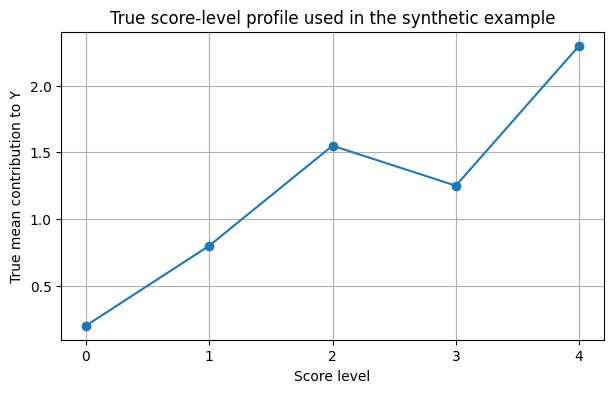

In [6]:
true_mu_df = pd.DataFrame({
    "level": list(true_mu.keys()),
    "true_mu": list(true_mu.values())
}).sort_values("level")

display(true_mu_df)

plt.figure(figsize=(7, 4))
plt.plot(true_mu_df["level"], true_mu_df["true_mu"], marker="o")
plt.title("True score-level profile used in the synthetic example")
plt.xlabel("Score level")
plt.ylabel("True mean contribution to Y")
plt.xticks(range(5))
plt.show()


## 6. Instantiate the scorer

The most important constructor arguments are:

- `df_spline`: number of knots used by the sparse spline transformer,
- `min_n`: minimum count required for both levels of a transition,
- `min_k`: minimum number of valid transitions required to keep a `k` score,
- `min_gain`: optional gain margin added to the lower level before computing a transition,
- `w_avg`, `w_min`, `w_neg`, `w_viol`: weights used in the `score_k` formula.

The class also expects a scale parameter `sigma` before calling `evaluation_scoring`, because the implementation divides `Y` by `sigma` before fitting the spline.


In [7]:
scorer = Scoring(
    df_spline=6,
    min_n=20,
    min_k=1,
    min_gain=[0.0, 0.0, 0.0, 0.0],
    w_avg=1.0,
    w_min=1.0,
    w_neg=1.0,
    w_viol=1.0,
)

# Common practical choice: use the empirical standard deviation of Y
sigma = float(df["Y"].std(ddof=0))
scorer.set_sigma(sigma)

print("sigma =", sigma)


sigma = 0.674754929793969


## 7. Fit the spline model directly

The method below is the main estimation engine:

```python
mu, mu_dense, fit = scorer.fit_spline_mu(df_for_fit)
```

Internally, your code:

1. clips the score to \([0, 4]\),
2. builds a B-spline basis with `SplineTransformer`,
3. adds sparse one-hot fixed effects for zone/date **only when informative**,
4. adds a second-difference curvature penalty to the spline coefficients,
5. solves the augmented least-squares system with `scipy.sparse.linalg.lsqr`.

### Fixed-effect inclusion rule

The implementation keeps a fixed effect only when it is informative:

```python
use_zone_fe = (1 < n_zone_unique < n)
use_date_fe = (1 < n_date_unique < n)
```

So a fixed effect is **removed** when:

- there is only one zone/date in the sample,
- or there is one unique zone/date per observation.


In [8]:
df_fit = df[["score", "Y", "zone", "date"]].copy()

mu, mu_dense, fit = scorer.fit_spline_mu(df_fit)

display(pd.DataFrame({
    "level": list(mu.keys()),
    "mu": list(mu.values())
}))

print("use_zone_fe =", fit["use_zone_fe"])
print("use_date_fe =", fit["use_date_fe"])
print("n_basis     =", fit["n_basis"])
print("n_zone_fe   =", fit["n_zone_fe"])
print("n_date_fe   =", fit["n_date_fe"])


,level,mu
0,0,0.153666
1,1,0.834696
2,2,1.516809
3,3,1.279210
4,4,2.291116


use_zone_fe = True
use_date_fe = True
n_basis     = 7
n_zone_fe   = 11
n_date_fe   = 119


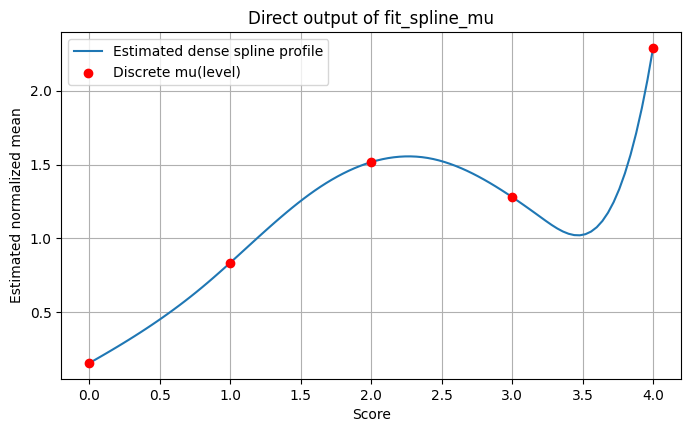

In [9]:
x_dense = np.linspace(0, 4, len(mu_dense))

plt.figure(figsize=(8, 4.5))
plt.plot(x_dense, mu_dense, label="Estimated dense spline profile")
plt.scatter(list(mu.keys()), list(mu.values()), color="red", zorder=3, label="Discrete mu(level)")
plt.xlabel("Score")
plt.ylabel("Estimated normalized mean")
plt.title("Direct output of fit_spline_mu")
plt.legend()
plt.show()


## 8. Optional comparison with the dense/classic implementation

`fit_spline_mu_classic` uses the formula interface of statsmodels with:

\[
Y \sim bs(score) + C(zone) + C(date)
\]

This version is useful for debugging or small datasets, but the sparse implementation is generally the better choice for large fixed-effect structures.

The cell below runs only if `fit_spline_mu_classic` is available in the namespace.


,level,mu_classic,mu_sparse
0,0,0.216559,0.153666
1,1,0.743002,0.834696
2,2,1.477113,1.516809
3,3,1.197656,1.279210
4,4,2.227702,2.291116


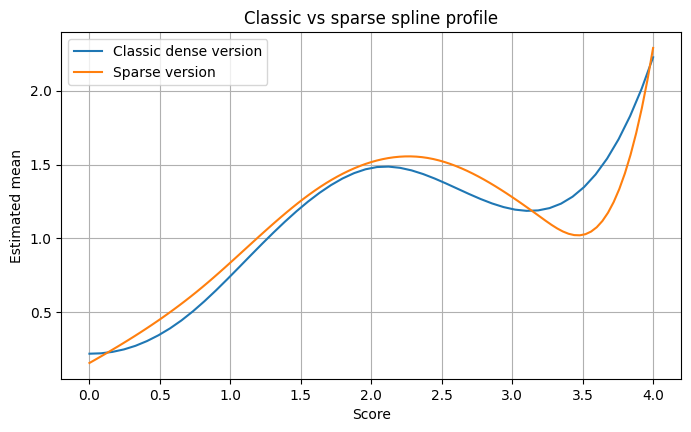

In [10]:
if "fit_spline_mu_classic" in globals():
    mu_classic, mu_dense_classic, fit_classic = fit_spline_mu_classic(df_fit, df_spline=5)

    display(pd.DataFrame({
        "level": list(mu_classic.keys()),
        "mu_classic": list(mu_classic.values()),
        "mu_sparse": [mu[k] for k in sorted(mu.keys())],
    }))

    plt.figure(figsize=(8, 4.5))
    plt.plot(np.linspace(0, 4, len(mu_dense_classic)), mu_dense_classic, label="Classic dense version")
    plt.plot(np.linspace(0, 4, len(mu_dense)), mu_dense, label="Sparse version")
    plt.xlabel("Score")
    plt.ylabel("Estimated mean")
    plt.title("Classic vs sparse spline profile")
    plt.legend()
    plt.show()
else:
    print("fit_spline_mu_classic is not defined in the current session.")


## 9. Reference normalization

A distinctive feature of your implementation is the optional **reference normalization**.

When `reference=True` in `evaluation_scoring`, the class stores:

```python
self.pair_mean_deltas[(a, b)] = delta_reference
```

but **only** for pairs with a strictly positive reference delta.

Later, when `reference=False`, each valid delta is normalized as:

\[
\Delta^{norm}_{a \to b}
=
\frac{\Delta_{a \to b}}{|\Delta^{ref}_{a \to b}|},
\]

using the stored reference value of that exact pair.

This makes different evaluations more comparable on a common transition scale.


In [11]:
# Use the same data as a reference set for demonstration.
# In practice, this is often the training set or a baseline calibration set.
ref_outputs = scorer.evaluation_scoring(
    ypred=df["score"].values,
    ytrue=df["Y"].values,
    dates=df["date"].values,
    zones=df["zone"].values,
    reference=True,
)

pair_ref = pd.DataFrame(
    [{"pair": f"{a}->{b}", "reference_delta": v} for (a, b), v in scorer.pair_mean_deltas.items()]
).sort_values("pair")

display(pair_ref)


,pair,reference_delta
0,0->1,1.009299
3,0->2,2.020205
6,0->3,1.668079
8,0->4,3.167743
1,1->2,1.010906
4,1->3,0.658779
7,1->4,2.158443
5,2->4,1.147537
2,3->4,1.499664


## 10. Full monotonic evaluation

The method

```python
score_high, score_low, coverage_k, score_adj_k, score_min_class, mu, mu_dense = scorer.evaluation_scoring(...)
```

returns:

- `score_high`: `k=3` plus `k=4`,
- `score_low`: `k=1` plus `k=2`,
- `coverage_k`: number of valid pairs for each order,
- `score_adj_k`: score by order,
- `score_min_class`: extra penalty linked to the smallest predicted class,
- `mu`, `mu_dense`: fitted profile used to build all transitions.


In [12]:
score_high, score_low, coverage_k, score_adj_k, score_min_class, mu_eval, mu_dense_eval = scorer.evaluation_scoring(
    ypred=df["score"].values,
    ytrue=df["Y"].values,
    dates=df["date"].values,
    zones=df["zone"].values,
    reference=False,
)

summary_eval = pd.DataFrame({
    "k": [1, 2, 3, 4],
    "coverage": [coverage_k.get(k, np.nan) for k in [1, 2, 3, 4]],
    "score_k": [score_adj_k.get(k, np.nan) for k in [1, 2, 3, 4]],
})
display(summary_eval)

print("score_low      =", score_low)
print("score_high     =", score_high)
print("score_total    =", score_low + score_high)
print("score_min_class=", score_min_class)


,k,coverage,score_k
0,1,4,0.213897
1,2,3,1.000000
2,3,2,1.000000
3,4,1,1.000000


score_low      = 1.2138974807477116
score_high     = 2.0
score_total    = 3.2138974807477116
score_min_class= 0.0


## 11. Reconstruct the score of each `k` step by step

The next cell rebuilds the exact ingredients used by the code for each order `k`:

1. list the valid pairs,
2. compute raw deltas,
3. normalize them by `pair_mean_deltas` when available,
4. compute:
   - median delta,
   - minimum delta,
   - negative mass,
   - violation rate,
5. combine them with the same formula as the class.


In [13]:
def breakdown_k_score(mu, lvl_counts, k, min_n, min_k, min_gain, pair_mean_deltas,
                      w_avg=1.0, w_min=1.0, w_neg=1.0, w_viol=1.0):
    rows = []
    deltas_norm = []

    for (a, b) in PASSAGES.get(k, []):
        n_a = lvl_counts.get(a, 0)
        n_b = lvl_counts.get(b, 0)
        valid = (n_a >= min_n) and (n_b >= min_n)

        if valid:
            delta_raw = mu[b] - (mu[a] + min_gain)
            denom = abs(pair_mean_deltas.get((a, b), 1.0)) or 1.0
            delta_norm = delta_raw / denom
            neg_part = max(-delta_norm, 0.0)
            violation = delta_norm < 0
            deltas_norm.append(delta_norm)
        else:
            delta_raw = np.nan
            denom = np.nan
            delta_norm = np.nan
            neg_part = np.nan
            violation = np.nan

        rows.append({
            "pair": f"{a}->{b}",
            "count_a": n_a,
            "count_b": n_b,
            "valid": valid,
            "delta_raw": delta_raw,
            "reference_scale": denom,
            "delta_norm": delta_norm,
            "neg_part": neg_part,
            "violation": violation,
        })

    details = pd.DataFrame(rows)

    valid_vals = details.loc[details["valid"], "delta_norm"].dropna().to_numpy()

    if len(valid_vals) < min_k or len(valid_vals) == 0:
        aggregate = {
            "k": k,
            "coverage": int(len(valid_vals)),
            "median_delta": 0.0,
            "min_delta": 0.0,
            "neg_mass": 0.0,
            "viol_rate": 0.0,
            "score_k": 0.0,
        }
        return details, aggregate

    median_delta = float(np.median(valid_vals))
    min_delta = float(np.min(valid_vals))
    neg_mass = float(np.mean(np.clip(-valid_vals, 0.0, None)))
    viol_rate = float(np.mean(valid_vals < 0.0))

    score_k = (
        (w_avg * median_delta + w_min * min_delta) / 2.0
        - w_neg * neg_mass * (1.0 + w_viol * viol_rate)
    )

    aggregate = {
        "k": k,
        "coverage": int(len(valid_vals)),
        "median_delta": median_delta,
        "min_delta": min_delta,
        "neg_mass": neg_mass,
        "viol_rate": viol_rate,
        "score_k": score_k,
    }
    return details, aggregate

lvl_counts = pd.Series(np.clip(df["score"].values, 0, 4).astype(int)).value_counts().to_dict()

all_details = []
all_agg = []

for k in [1, 2, 3, 4]:
    min_gain_k = scorer.min_gain[k - 1] if isinstance(scorer.min_gain, (list, tuple)) else scorer.min_gain
    d_k, a_k = breakdown_k_score(
        mu=mu_eval,
        lvl_counts=lvl_counts,
        k=k,
        min_n=scorer.min_n,
        min_k=scorer.min_k,
        min_gain=min_gain_k,
        pair_mean_deltas=scorer.pair_mean_deltas,
        w_avg=scorer.w_avg,
        w_min=scorer.w_min,
        w_neg=scorer.w_neg,
        w_viol=scorer.w_viol,
    )
    all_details.append(d_k.assign(k=k))
    all_agg.append(a_k)

details_df = pd.concat(all_details, ignore_index=True)
agg_df = pd.DataFrame(all_agg)

display(agg_df)
display(details_df)


,k,coverage,median_delta,min_delta,neg_mass,viol_rate,score_k
0,1,4,1.0,-0.352126,0.088032,0.25,0.213897
1,2,3,1.0,1.000000,0.000000,0.00,1.000000
2,3,2,1.0,1.000000,0.000000,0.00,1.000000
3,4,1,1.0,1.000000,0.000000,0.00,1.000000


,pair,count_a,count_b,valid,delta_raw,reference_scale,delta_norm,neg_part,violation,k
0,0->1,208,740,True,1.009299,1.009299,1.000000,0.000000,False,1
1,1->2,740,1203,True,1.010906,1.010906,1.000000,0.000000,False,1
2,2->3,1203,652,True,-0.352126,1.000000,-0.352126,0.352126,True,1
3,3->4,652,197,True,1.499664,1.499664,1.000000,0.000000,False,1
4,0->2,208,1203,True,2.020205,2.020205,1.000000,0.000000,False,2
5,1->3,740,652,True,0.658779,0.658779,1.000000,0.000000,False,2
6,2->4,1203,197,True,1.147537,1.147537,1.000000,0.000000,False,2
7,0->3,208,652,True,1.668079,1.668079,1.000000,0.000000,False,3
8,1->4,740,197,True,2.158443,2.158443,1.000000,0.000000,False,3
9,0->4,208,197,True,3.167743,3.167743,1.000000,0.000000,False,4


### Reading the breakdown table

For each pair `a->b`:

- `delta_raw` is the raw transition effect from the fitted \(\mu\) values,
- `reference_scale` is the stored positive reference delta for that pair,
- `delta_norm = delta_raw / reference_scale`,
- `neg_part = max(-delta_norm, 0)`,
- `violation = True` when the normalized transition is negative.

This is the most transparent way to understand **why** a given `k` score is positive, weak, or negative.


## 12. Plot 1 — global spline fit (`_plot`)

This plot combines:

- the dense spline fit `mu_dense`,
- the discrete class values `mu(0)...mu(4)`,
- the raw mean by predicted class,
- and a text box summarizing the low/high scores.

It is the best first plot to inspect the general shape of the estimated ordinal profile.


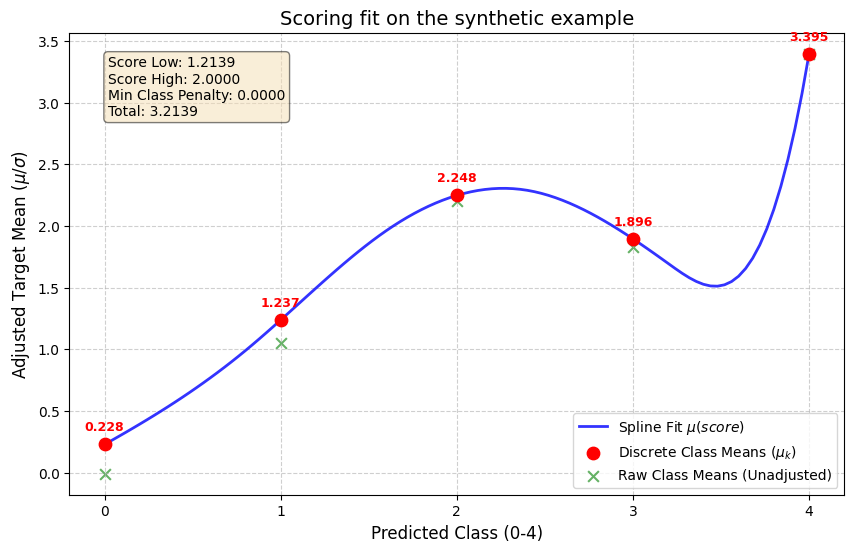

In [14]:
_ = scorer._plot(
    ypred=df["score"].values,
    ytrue=df["Y"].values,
    dates=df["date"].values,
    zones=df["zone"].values,
    title="Scoring fit on the synthetic example",
)


## 13. Plot 2 — transition matrix (`_plot_matrice`)

This heatmap shows all upper-triangular transitions \(a \to b\) with \(a < b\).

Interpretation:

- **green / positive** cells: monotonic increase,
- **red / negative** cells: monotonic violation,
- **grey / NA** cells: one of the two levels does not have enough support,
- the optional annotation `[n]` is the effective support `min(n_a, n_b)`.

This plot is ideal for locating **where** the monotonic structure breaks.


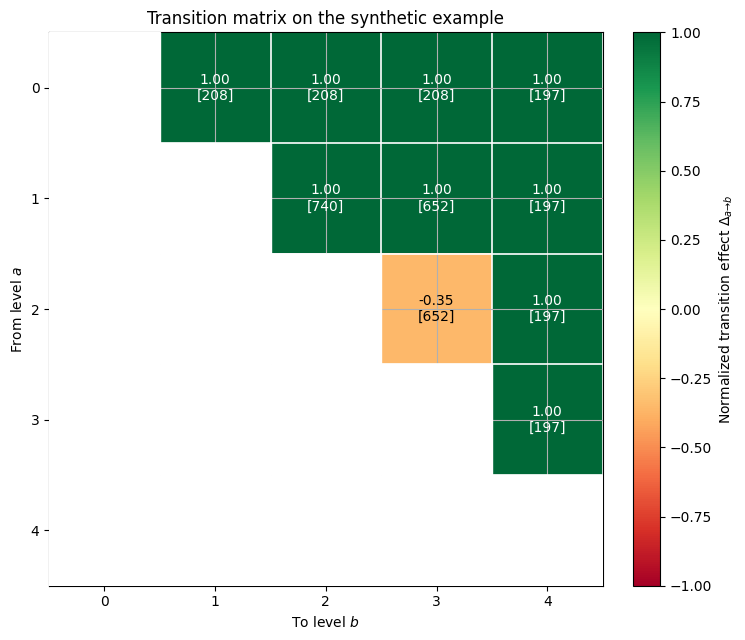

In [15]:
_ = scorer._plot_matrice(
    ypred=df["score"].values,
    ytrue=df["Y"].values,
    dates=df["date"].values,
    zones=df["zone"].values,
    title="Transition matrix on the synthetic example",
    normalize_with_reference=True,
    show_effective_coverage=True,
    annotate=True,
    figsize=(8.5, 6.5),
)


## 14. Plot 3 — fixed effects (`_plot_fixed_effects`)

This method visualizes the fixed-effect coefficients estimated by the sparse spline model.

- Zone fixed effects are shown as a horizontal bar chart.
- Date fixed effects are shown as a time series.

This plot is useful to verify whether the model is absorbing substantial spatial or temporal structure.


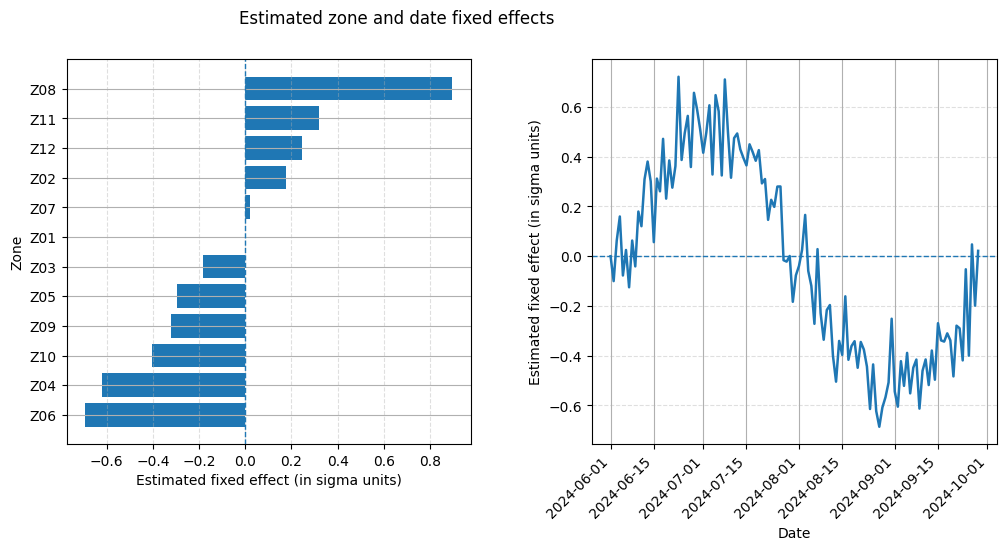

In [16]:
_ = scorer._plot_fixed_effects(
    ypred=df["score"].values,
    ytrue=df["Y"].values,
    dates=df["date"].values,
    zones=df["zone"].values,
    title="Estimated zone and date fixed effects",
    top_n_zone=12,
)


## 15. Full metric evaluation (`evaluate_metrics`)

`evaluate_metrics` combines classical metrics and the monotonic score in one dictionary.

In your implementation, this includes:

- `iou`,
- `f1`, `precision`, `recall`,
- macro versions of those metrics,
- `under`, `over`,
- entropy from class probabilities when available,
- the monotonic scores and the fitted `mu` values.

The cell below uses a simple one-hot probability matrix only to make the entropy term finite in this standalone notebook.


In [17]:
y_true = df["score"].values.astype(int)
y_pred = df["score"].values.astype(int)

# Simple demo probabilities: peaked on the predicted class
probas = np.full((len(y_pred), 5), 0.05)
probas[np.arange(len(y_pred)), y_pred] = 0.80
probas = probas / probas.sum(axis=1, keepdims=True)

metrics = scorer.evaluate_metrics(
    y_true=y_true,
    y_pred=y_pred,
    dates=df["date"].values,
    zones=df["zone"].values,
    y_pred_probas=probas,
    reference=False,
)

metrics_df = pd.DataFrame({
    "metric": list(metrics.keys()),
    "value": list(metrics.values()),
})

display(metrics_df.head(20))


,metric,value
0,iou,1.000000
1,f1,1.000000
2,under,0.000000
3,over,0.000000
4,prec,1.000000
5,recall,1.000000
6,auoc,-1.000000
7,f1_macro,1.000000
8,prec_macro,1.000000
9,rec_macro,1.000000


## 16. Recommended usage pattern on real data

A practical workflow is:

1. **Instantiate** the scorer with the transition hyperparameters.
2. **Set `sigma`** on a reference scale (often the standard deviation of the target on the reference set).
3. **Run `evaluation_scoring(..., reference=True)`** on a reference set to populate `pair_mean_deltas`.
4. **Evaluate candidate predictions** with `reference=False`.
5. Use:
   - `_plot` for the global ordinal shape,
   - `_plot_matrice` for transition diagnostics,
   - `_plot_fixed_effects` to inspect zone/date structure.


In [18]:
# Template for real data
# df_real must contain: score, Y, zone, date

# scorer = Scoring(df_spline=6, min_n=5, min_k=1, min_gain=[0, 0, 0, 0])
# scorer.set_sigma(df_train["Y"].std(ddof=0))

# scorer.evaluation_scoring(
#     ypred=df_train["score"].values,
#     ytrue=df_train["Y"].values,
#     dates=df_train["date"].values,
#     zones=df_train["zone"].values,
#     reference=True,
# )

# score_high, score_low, coverage_k, score_adj_k, score_min_class, mu, mu_dense = scorer.evaluation_scoring(
#     ypred=df_test["score"].values,
#     ytrue=df_test["Y"].values,
#     dates=df_test["date"].values,
#     zones=df_test["zone"].values,
#     reference=False,
# )


## 17. Common pitfalls

### A. Forgetting to set `sigma`
`evaluation_scoring` divides `Y` by `self.sigma`.  
So `scorer.set_sigma(...)` should be called before the first evaluation.

### B. Missing external definitions
`evaluate_metrics` needs the helper functions and `PASSAGES`.  
If they are not defined in the current session, the method will fail.

### C. Fixed effects may be intentionally disabled
This is not a bug.  
The implementation removes `zone` or `date` fixed effects when they are not informative, i.e. when:

- there is only one unique level,
- or each observation has its own unique level.

### D. Interpretation of `score_min_class`
This is a separate penalty term.  
It is not part of `score_low` or `score_high`.

### E. Transition coverage matters
A `k` score with very low coverage should be interpreted cautiously, even if its value looks large in magnitude.


## 18. Final interpretation guide

A useful reading strategy is:

- start with `_plot` to inspect the global shape;
- then inspect `_plot_matrice` to locate violations or especially strong gains;
- finally inspect `_plot_fixed_effects` to see whether spatial or temporal heterogeneity dominates the target.

In general:

- a **good ordinal signal** should produce mostly positive transitions,
- a **local inconsistency** often appears first in the matrix plot,
- and **strong fixed effects** indicate that score effects should be interpreted conditionally on zone/date structure rather than on raw averages alone.


## 19. References

This notebook relies on the official documentation of the numerical tools used by your implementation:

1. scikit-learn, `SplineTransformer`:  
   <https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.SplineTransformer.html>

2. scikit-learn, `OneHotEncoder`:  
   <https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.OneHotEncoder.html>

3. SciPy, `scipy.sparse.linalg.lsqr`:  
   <https://docs.scipy.org/doc/scipy/reference/generated/scipy.sparse.linalg.lsqr.html>

4. statsmodels, formula API `ols`:  
   <https://www.statsmodels.org/stable/generated/statsmodels.formula.api.ols.html>

5. Patsy, spline regression and `bs(...)`:  
   <https://patsy.readthedocs.io/en/latest/spline-regression.html>

All equations describing `score_k`, `score_low`, `score_high`, the reference normalization, and the fixed-effect inclusion rule are direct transcriptions of the implementation logic provided in your class.
